# Гипотезы
## Базовые гипотезы
1. Доля серьезных случаев(serious cases) различается между возрастными группами.
2. Доля серьезных случаев(serious cases) различается между полом.
3. Среднее количество дней до появления симптомов(time_to_onset_days) различается между серьезными и не серьезными случаями(serious и non-serious cases).
4. Средняя продолжительность дней(event_duration_days) различается между исходами(outcome) - групп.

## Средний уровень
1. Доля серьезных случаев(serious cases) у подозрительных препаратов(suspect_drug).
2. Доля неблагоприятных исходов(outcomes) между route.
3. Тип заявителя(reporter_type) связан с оценкой причинно-следственной связи(causality_assessment).
4. У пациентов с более высокими лабораторными показателями чаще встречаются серьезные случаи(serious cases).

## Финальные гипотезы
1. После стратификации по возрасту и полу различия между препаратами сохраняются.
2. После поправки Bonferroni часть значимых различий исчезает.
3. Bootstrap подтверждает устойчивость оценок для ключевых метрик.
4. Случайный A/A split не показывает устойчивых различий, а искусственный A/B split показывает ожидаемый эффект.

Бизнес-запрос:
Статистический анализ факторов, связанных с тяжестью и исходами нежелательных явлений.

Основной бизнес-вопрос:
Какие факторы статистически связаны с тяжёлыми неблагоприятными результатами, и насколько устойчивы эти выводы при разных методах проверки?


Целевая аналитическая логика:
Основная target-метрика:
1. seriousness

Дополнительные target-метрики:
1. outcome
2. causality_assessment

### Этап 1. Подготовка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import polars as pl
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.stats import ttest_ind

In [ ]:
df = pl.read_csv('/content/drive/MyDrive/Colab Notebooks/synthetic_faers_1m_v3.csv')
df.head(10)

case_id,receive_date,country,age,age_group,sex,weight_kg,suspect_drug,indication,route,dose,dose_unit,dose_frequency,treatment_duration_days,event_llt,event_pt,event_hlt,event_hlgt,event_soc,time_to_onset_days,event_duration_days,seriousness,outcome,action_taken,dechallenge,rechallenge,concomitant_medications,medical_history,reporter_type,report_type,causality_assessment,alt_u_l,ast_u_l,bilirubin_mg_dl,creatinine_mg_dl,bun_mg_dl
str,str,str,i64,str,str,f64,str,str,str,i64,str,str,f64,str,str,str,str,str,i64,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64
"""E787C9A1FC17D940""","""2023-04-19""","""CHN""",52,"""adult""","""Unknown""",null,"""Hematocare""","""Hypothyroidism""","""Subcutaneous""",5,"""mg""","""Four times daily""",688.0,"""High blood pressure""","""Deep vein thrombosis""","""Hypertension""","""Vascular hypertensive disorder…","""Vascular disorders""",29,null,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Aspirin""",null,"""Physician""","""Spontaneous""","""Probable/Likely""",12.0,12.0,0.4,1.0,16.0
"""A29236736650CAB3""","""2021-10-30""","""POL""",45,"""adult""","""Male""",110.5,"""Osteostrong""","""Bipolar disorder""","""Intravenous""",50,"""mg""","""Four times daily""",348.0,"""AKI""","""Acute kidney injury""","""Acute renal failures""","""Renal failures and impairments""","""Renal and urinary disorders""",7,69.0,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Hydrochlorothiazide""",null,"""Consumer""","""Clinical trial""","""Probable/Likely""",15.0,null,0.5,7.1,46.0
"""837A1C25D1B0ED72""","""2021-09-12""","""ITA""",92,"""elderly""","""Female""",null,"""Hematocare""","""COPD""","""Subcutaneous""",1,"""mg""","""As needed""",556.0,"""Hepatic injury""","""Hepatotoxicity""","""Liver failures and associated …","""Liver disorders""","""Hepatobiliary disorders""",45,null,"""Non-serious""","""Recovering/Resolving""","""Not applicable""","""Not applicable""","""Not applicable""",null,"""Hyperlipidemia; Alcohol use di…","""Physician""","""Spontaneous""","""Possible""",340.0,null,9.5,0.9,15.0
"""BF1523DD99667C0D""","""2021-10-03""","""USA""",47,"""adult""","""Male""",115.0,"""Vasodilate""","""Schizophrenia""","""Ophthalmic""",1,"""mg""","""Once daily""",null,"""Erythema multiforme""","""Toxic epidermal necrolysis""","""Rashes, eruptions and exanthem…","""Epidermal and dermal condition…","""Skin and subcutaneous tissue d…",5,45.0,"""Non-serious""","""Recovered with sequelae""","""Dose reduced""","""Not applicable""","""Not applicable""",null,"""Peripheral vascular disease; H…","""Consumer""","""Spontaneous""","""Possible""",45.0,null,1.1,1.2,9.0
"""F470F722F96A2FF7""","""2021-03-08""","""GBR""",19,"""adult""","""Female""",94.4,"""Cardiomax""","""Rheumatoid arthritis""","""Intramuscular""",5,"""mg""","""Twice daily""",453.0,"""Hyperthyroidism""","""Diabetes mellitus""","""Hyperglycaemic conditions NEC""","""Glucose metabolism disorders""","""Endocrine disorders""",174,null,"""Other medically important cond…","""Recovered with sequelae""","""Dose increased""","""Not applicable""","""Not applicable""","""Pantoprazole; Hydrochlorothiaz…",null,"""Pharmacist""","""Spontaneous""","""Unlikely""",33.0,35.0,0.1,1.1,12.0
"""785B2438894CDCFA""","""2025-08-05""","""ESP""",89,"""elderly""","""Male""",111.7,"""Eyeprotect""","""Rheumatoid arthritis""","""Topical""",2,"""mg""","""Three times daily""",null,"""AKI""","""Acute kidney injury""","""Acute renal failures""","""Renal failures and impairments""","""Renal and urinary disorders""",2,61.0,"""Disability""","""Recovered/Resolved""","""Not applicable""","""Not applicable""","""Not applicable""","""Warfarin; Aspirin""","""Osteoarthritis; Depression""","""Other health professional""","""Literature""","""Possible""",27.0,26.0,1.2,null,null
"""5A0796C50364BAA5""","""2023-04-29""","""CAN""",58,"""adult""","""Unknown""",58.1,"""Immunoshield""","""Type 2 diabetes""","""Top

In [ ]:
df.columns

['case_id',
 'receive_date',
 'country',
 'age',
 'age_group',
 'sex',
 'weight_kg',
 'suspect_drug',
 'indication',
 'route',
 'dose',
 'dose_unit',
 'dose_frequency',
 'treatment_duration_days',
 'event_llt',
 'event_pt',
 'event_hlt',
 'event_hlgt',
 'event_soc',
 'time_to_onset_days',
 'event_duration_days',
 'seriousness',
 'outcome',
 'action_taken',
 'dechallenge',
 'rechallenge',
 'concomitant_medications',
 'medical_history',
 'reporter_type',
 'report_type',
 'causality_assessment',
 'alt_u_l',
 'ast_u_l',
 'bilirubin_mg_dl',
 'creatinine_mg_dl',
 'bun_mg_dl']

In [ ]:
# Пропуски
df.null_count().transpose(
    include_header=True,
    header_name="column",
    column_names=["null_count"]
).filter(
    pl.col("null_count") > 0
)

column,null_count
str,u32
"""weight_kg""",349118
"""dose_frequency""",200049
"""treatment_duration_days""",300230
"""event_duration_days""",400543
"""concomitant_medications""",199925
…,…
"""alt_u_l""",249260
"""ast_u_l""",250046
"""bilirubin_mg_dl""",250589


In [ ]:
for col in df.columns:
    null_count = df.select(pl.col(col).null_count()).item()
    if null_count > 0:
        print(col, null_count)

weight_kg 349118
dose_frequency 200049
treatment_duration_days 300230
event_duration_days 400543
concomitant_medications 199925
medical_history 150362
alt_u_l 249260
ast_u_l 250046
bilirubin_mg_dl 250589
creatinine_mg_dl 249910
bun_mg_dl 250732


In [ ]:
# Версия с удалением пустых значений
df_model = df.clone()

In [ ]:
# Подготовка категорий для статистики
df_model = df_model.with_columns(
    pl.when(pl.col("age").is_null()).then(pl.lit("Нет данных"))
      .when(pl.col("age") < 18).then(pl.lit("<18"))
      .when(pl.col("age") < 30).then(pl.lit("18-29"))
      .when(pl.col("age") < 45).then(pl.lit("30-44"))
      .when(pl.col("age") < 60).then(pl.lit("45-59"))
      .when(pl.col("age") < 75).then(pl.lit("60-74"))
      .otherwise(pl.lit("75+"))
      .alias("age_group"),

    pl.when(pl.col("weight_kg").is_null()).then(pl.lit("Нет данных"))
      .when(pl.col("weight_kg") < 50).then(pl.lit("<50"))
      .when(pl.col("weight_kg") < 70).then(pl.lit("50-69"))
      .when(pl.col("weight_kg") < 90).then(pl.lit("70-89"))
      .when(pl.col("weight_kg") < 110).then(pl.lit("90-109"))
      .otherwise(pl.lit("110+"))
      .alias("weight_group"),

    pl.when(pl.col("dose").is_null()).then(pl.lit("Нет данных"))
      .when(pl.col("dose") < 10).then(pl.lit("<10"))
      .when(pl.col("dose") < 50).then(pl.lit("10-49"))
      .when(pl.col("dose") < 100).then(pl.lit("50-99"))
      .when(pl.col("dose") < 500).then(pl.lit("100-499"))
      .otherwise(pl.lit("500+"))
      .alias("dose_group"),

    pl.when(pl.col("event_duration_days").is_null()).then(pl.lit("Нет данных"))
      .when(pl.col("event_duration_days") <= 7).then(pl.lit("0-7 дней"))
      .when(pl.col("event_duration_days") <= 30).then(pl.lit("8-30 дней"))
      .when(pl.col("event_duration_days") <= 90).then(pl.lit("31-90 дней"))
      .otherwise(pl.lit("90+ дней"))
      .alias("event_duration_group")
)
df_model.head(5)

case_id,receive_date,country,age,age_group,sex,weight_kg,suspect_drug,indication,route,dose,dose_unit,dose_frequency,treatment_duration_days,event_llt,event_pt,event_hlt,event_hlgt,event_soc,time_to_onset_days,event_duration_days,seriousness,outcome,action_taken,dechallenge,rechallenge,concomitant_medications,medical_history,reporter_type,report_type,causality_assessment,alt_u_l,ast_u_l,bilirubin_mg_dl,creatinine_mg_dl,bun_mg_dl,weight_group,dose_group,event_duration_group
str,str,str,i64,str,str,f64,str,str,str,i64,str,str,f64,str,str,str,str,str,i64,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,str,str
"""E787C9A1FC17D940""","""2023-04-19""","""CHN""",52,"""45-59""","""Unknown""",null,"""Hematocare""","""Hypothyroidism""","""Subcutaneous""",5,"""mg""","""Four times daily""",688.0,"""High blood pressure""","""Deep vein thrombosis""","""Hypertension""","""Vascular hypertensive disorder…","""Vascular disorders""",29,null,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Aspirin""",null,"""Physician""","""Spontaneous""","""Probable/Likely""",12.0,12.0,0.4,1.0,16.0,"""Нет данных""","""<10""","""Нет данных"""
"""A29236736650CAB3""","""2021-10-30""","""POL""",45,"""45-59""","""Male""",110.5,"""Osteostrong""","""Bipolar disorder""","""Intravenous""",50,"""mg""","""Four times daily""",348.0,"""AKI""","""Acute kidney injury""","""Acute renal failures""","""Renal failures and impairments""","""Renal and urinary disorders""",7,69.0,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Hydrochlorothiazide""",null,"""Consumer""","""Clinical trial""","""Probable/Likely""",15.0,null,0.5,7.1,46.0,"""110+""","""50-99""","""31-90 дней"""
"""837A1C25D1B0ED72""","""2021-09-12""","""ITA""",92,"""75+""","""Female""",null,"""Hematocare""","""COPD""","""Subcutaneous""",1,"""mg""","""As needed""",556.0,"""Hepatic injury""","""Hepatotoxicity""","""Liver failures and associated …","""Liver disorders""","""Hepatobiliary disorders""",45,null,"""Non-serious""","""Recovering/Resolving""","""Not applicable""","""Not applicable""","""Not applicable""",null,"""Hyperlipidemia; Alcohol use di…","""Physician""","""Spontaneous""","""Possible""",340.0,null,9.5,0.9,15.0,"""Нет данных""","""<10""","""Нет данных"""
"""BF1523DD99667C0D""","""2021-10-03""","""USA""",47,"""45-59""","""Male""",115.0,"""Vasodilate""","""Schizophrenia""","""Ophthalmic""",1,"""mg""","""Once daily""",null,"""Erythema multiforme""","""Toxic epidermal necrolysis""","""Rashes, eruptions and exanthem…","""Epidermal and dermal condition…","""Skin and subcutaneous tissue d…",5,45.0,"""Non-serious""","""Recovered with sequelae""","""Dose reduced""","""Not applicable""","""Not applicable""",null,"""Peripheral vascular disease; H…","""Consumer""","""Spontaneous""","""Possible""",45.0,null,1.1,1.2,9.0,"""110+""","""<10""","""31-90 дней"""
"""F470F722F96A2FF7""","""2021-03-08""","""GBR""",19,"""18-29""","""Female""",94.4,"""Cardiomax""","""Rheumatoid arthritis""","""Intramuscular""",5,"""mg""","""Twice daily""",453.0,"""Hyperthyroidism""","""Diabetes mellitus""","""Hyperglycaemic conditions NEC""","""Glucose metabolism disorders""","""Endocrine disorders""",174,null,"""Other medically important cond…","""Recovered with sequelae""","""Dose increased""","""Not applicable""","""Not applicable""","""Pantoprazole; Hydrochlorothiaz…",null,"""Pharmacist""","""Spontaneous""","""Unlikely""",33.0,35.0,0.1,1.1,12.0,"""90-109""","""<10""","""Нет данных"""


In [ ]:
# Пороговые значения для лабораторных показателей
ALT_HIGH_THRESHOLD = 40  # это порог повышенного ALT, фермента печени
AST_HIGH_THRESHOLD = 40  # это порог повышенного AST, фермента печени
BILIRUBIN_HIGH_THRESHOLD = 1.2  # это порог повышенного билирубина, показателя работы печени
CREATININE_HIGH_THRESHOLD = 1.2  # это порог повышенного креатинина, показателя работы почек
BUN_HIGH_THRESHOLD = 20  # это порог повышенного BUN, азота мочевины крови, показателя работы почек


df_model = df_model.with_columns(
    # Флаг серьезного случая
    pl.when(pl.col("seriousness").is_null()).then(None)
      .when(pl.col("seriousness") == "Non-serious").then(pl.lit(0))
      .otherwise(pl.lit(1))
      .cast(pl.Int8)
      .alias("is_serious"),

    # Флаг повышенного ALT
    pl.when(pl.col("alt_u_l").is_null()).then(None)
      .when(pl.col("alt_u_l") > ALT_HIGH_THRESHOLD).then(pl.lit(1))
      .otherwise(pl.lit(0))
      .cast(pl.Int8)
      .alias("is_alt_high"),

    # Флаг повышенного AST
    pl.when(pl.col("ast_u_l").is_null()).then(None)
      .when(pl.col("ast_u_l") > AST_HIGH_THRESHOLD).then(pl.lit(1))
      .otherwise(pl.lit(0))
      .cast(pl.Int8)
      .alias("is_ast_high"),

    # Флаг повышенного билирубина
    pl.when(pl.col("bilirubin_mg_dl").is_null()).then(None)
      .when(pl.col("bilirubin_mg_dl") > BILIRUBIN_HIGH_THRESHOLD).then(pl.lit(1))
      .otherwise(pl.lit(0))
      .cast(pl.Int8)
      .alias("is_bilirubin_high"),

    # Флаг повышенного креатинина
    pl.when(pl.col("creatinine_mg_dl").is_null()).then(None)
      .when(pl.col("creatinine_mg_dl") > CREATININE_HIGH_THRESHOLD).then(pl.lit(1))
      .otherwise(pl.lit(0))
      .cast(pl.Int8)
      .alias("is_creatinine_high"),

    # Общий флаг: есть ли повышенные значения печени
    pl.when(
        pl.col("alt_u_l").is_null() &
        pl.col("ast_u_l").is_null() &
        pl.col("bilirubin_mg_dl").is_null()
    )
    .then(None)
    .when(
        (pl.col("alt_u_l") > ALT_HIGH_THRESHOLD) |
        (pl.col("ast_u_l") > AST_HIGH_THRESHOLD) |
        (pl.col("bilirubin_mg_dl") > BILIRUBIN_HIGH_THRESHOLD)
    )
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .cast(pl.Int8)
    .alias("has_liver_marker_high"),  # Превышены показания печени

    # Общий флаг: есть ли повышенные значения почек
    pl.when(
        pl.col("creatinine_mg_dl").is_null() &
        pl.col("bun_mg_dl").is_null()
    )
    .then(None)
    .when(
        (pl.col("creatinine_mg_dl") > CREATININE_HIGH_THRESHOLD) |
        (pl.col("bun_mg_dl") > BUN_HIGH_THRESHOLD)
    )
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .cast(pl.Int8)
    .alias("has_kidney_marker_high")  # Превышены показания почек
)
df_model.head(5)

case_id,receive_date,country,age,age_group,sex,weight_kg,suspect_drug,indication,route,dose,dose_unit,dose_frequency,treatment_duration_days,event_llt,event_pt,event_hlt,event_hlgt,event_soc,time_to_onset_days,event_duration_days,seriousness,outcome,action_taken,dechallenge,rechallenge,concomitant_medications,medical_history,reporter_type,report_type,causality_assessment,alt_u_l,ast_u_l,bilirubin_mg_dl,creatinine_mg_dl,bun_mg_dl,weight_group,dose_group,event_duration_group,is_serious,is_alt_high,is_ast_high,is_bilirubin_high,is_creatinine_high,has_liver_marker_high,has_kidney_marker_high
str,str,str,i64,str,str,f64,str,str,str,i64,str,str,f64,str,str,str,str,str,i64,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,str,str,i8,i8,i8,i8,i8,i8,i8
"""E787C9A1FC17D940""","""2023-04-19""","""CHN""",52,"""45-59""","""Unknown""",null,"""Hematocare""","""Hypothyroidism""","""Subcutaneous""",5,"""mg""","""Four times daily""",688.0,"""High blood pressure""","""Deep vein thrombosis""","""Hypertension""","""Vascular hypertensive disorder…","""Vascular disorders""",29,null,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Aspirin""",null,"""Physician""","""Spontaneous""","""Probable/Likely""",12.0,12.0,0.4,1.0,16.0,"""Нет данных""","""<10""","""Нет данных""",0,0,0,0,0,0,0
"""A29236736650CAB3""","""2021-10-30""","""POL""",45,"""45-59""","""Male""",110.5,"""Osteostrong""","""Bipolar disorder""","""Intravenous""",50,"""mg""","""Four times daily""",348.0,"""AKI""","""Acute kidney injury""","""Acute renal failures""","""Renal failures and impairments""","""Renal and urinary disorders""",7,69.0,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Hydrochlorothiazide""",null,"""Consumer""","""Clinical trial""","""Probable/Likely""",15.0,null,0.5,7.1,46.0,"""110+""","""50-99""","""31-90 дней""",0,0,null,0,1,0,1
"""837A1C25D1B0ED72""","""2021-09-12""","""ITA""",92,"""75+""","""Female""",null,"""Hematocare""","""COPD""","""Subcutaneous""",1,"""mg""","""As needed""",556.0,"""Hepatic injury""","""Hepatotoxicity""","""Liver failures and associated …","""Liver disorders""","""Hepatobiliary disorders""",45,null,"""Non-serious""","""Recovering/Resolving""","""Not applicable""","""Not applicable""","""Not applicable""",null,"""Hyperlipidemia; Alcohol use di…","""Physician""","""Spontaneous""","""Possible""",340.0,null,9.5,0.9,15.0,"""Нет данных""","""<10""","""Нет данных""",0,1,null,1,0,1,0
"""BF1523DD99667C0D""","""2021-10-03""","""USA""",47,"""45-59""","""Male""",115.0,"""Vasodilate""","""Schizophrenia""","""Ophthalmic""",1,"""mg""","""Once daily""",null,"""Erythema multiforme""","""Toxic epidermal necrolysis""","""Rashes, eruptions and exanthem…","""Epidermal and dermal condition…","""Skin and subcutaneous tissue d…",5,45.0,"""Non-serious""","""Recovered with sequelae""","""Dose reduced""","""Not applicable""","""Not applicable""",null,"""Peripheral vascular disease; H…","""Consumer""","""Spontaneous""","""Possible""",45.0,null,1.1,1.2,9.0,"""110+""","""<10""","""31-90 дней""",0,1,null,0,0,1,0
"""F470F722F96A2FF7""","""2021-03-08""","""GBR""",19,"""18-29""","""Female""",94.4,"""Cardiomax""","""Rheumatoid arthritis""","""Intramuscular""",5,"""mg""","""Twice daily""",453.0,"""Hyperthyroidism""","""Diabetes mellitus""","""Hyperglycaemic conditions NEC""","""Glucose metabolism disorders""","""Endocrine disorders""",174,null,"""Other medically important cond…","""Recovered with sequelae""","""Dose increased""","""Not applicable""","""Not applicable""","""Pantoprazole; Hydrochlorothiaz…",null,"""Pharmacist""","""Spontaneous""","""Unlikely""",33.0,35.0,0.1,1.1,12.0,"""90-109""","""<10""","""Нет данных""",1,0,0,0,0,0,0


In [ ]:
# Не обязательно
df_model = df_model.with_columns(
    pl.col("reporter_type").replace({
        "Physician": "Врач",
        "Consumer": "Пациент/потребитель",
        "Lawyer": "Юрист",
        "Other health professional": "Другой мед. специалист",
        "Pharmacist": "Фармацевт",
    }).alias("reporter_type_ru")
)
df_model.head(5)

case_id,receive_date,country,age,age_group,sex,weight_kg,suspect_drug,indication,route,dose,dose_unit,dose_frequency,treatment_duration_days,event_llt,event_pt,event_hlt,event_hlgt,event_soc,time_to_onset_days,event_duration_days,seriousness,outcome,action_taken,dechallenge,rechallenge,concomitant_medications,medical_history,reporter_type,report_type,causality_assessment,alt_u_l,ast_u_l,bilirubin_mg_dl,creatinine_mg_dl,bun_mg_dl,weight_group,dose_group,event_duration_group,is_serious,is_alt_high,is_ast_high,is_bilirubin_high,is_creatinine_high,has_liver_marker_high,has_kidney_marker_high,reporter_type_ru
str,str,str,i64,str,str,f64,str,str,str,i64,str,str,f64,str,str,str,str,str,i64,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,str,str,i8,i8,i8,i8,i8,i8,i8,str
"""E787C9A1FC17D940""","""2023-04-19""","""CHN""",52,"""45-59""","""Unknown""",null,"""Hematocare""","""Hypothyroidism""","""Subcutaneous""",5,"""mg""","""Four times daily""",688.0,"""High blood pressure""","""Deep vein thrombosis""","""Hypertension""","""Vascular hypertensive disorder…","""Vascular disorders""",29,null,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Aspirin""",null,"""Physician""","""Spontaneous""","""Probable/Likely""",12.0,12.0,0.4,1.0,16.0,"""Нет данных""","""<10""","""Нет данных""",0,0,0,0,0,0,0,"""Врач"""
"""A29236736650CAB3""","""2021-10-30""","""POL""",45,"""45-59""","""Male""",110.5,"""Osteostrong""","""Bipolar disorder""","""Intravenous""",50,"""mg""","""Four times daily""",348.0,"""AKI""","""Acute kidney injury""","""Acute renal failures""","""Renal failures and impairments""","""Renal and urinary disorders""",7,69.0,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Hydrochlorothiazide""",null,"""Consumer""","""Clinical trial""","""Probable/Likely""",15.0,null,0.5,7.1,46.0,"""110+""","""50-99""","""31-90 дней""",0,0,null,0,1,0,1,"""Пациент/потребитель"""
"""837A1C25D1B0ED72""","""2021-09-12""","""ITA""",92,"""75+""","""Female""",null,"""Hematocare""","""COPD""","""Subcutaneous""",1,"""mg""","""As needed""",556.0,"""Hepatic injury""","""Hepatotoxicity""","""Liver failures and associated …","""Liver disorders""","""Hepatobiliary disorders""",45,null,"""Non-serious""","""Recovering/Resolving""","""Not applicable""","""Not applicable""","""Not applicable""",null,"""Hyperlipidemia; Alcohol use di…","""Physician""","""Spontaneous""","""Possible""",340.0,null,9.5,0.9,15.0,"""Нет данных""","""<10""","""Нет данных""",0,1,null,1,0,1,0,"""Врач"""
"""BF1523DD99667C0D""","""2021-10-03""","""USA""",47,"""45-59""","""Male""",115.0,"""Vasodilate""","""Schizophrenia""","""Ophthalmic""",1,"""mg""","""Once daily""",null,"""Erythema multiforme""","""Toxic epidermal necrolysis""","""Rashes, eruptions and exanthem…","""Epidermal and dermal condition…","""Skin and subcutaneous tissue d…",5,45.0,"""Non-serious""","""Recovered with sequelae""","""Dose reduced""","""Not applicable""","""Not applicable""",null,"""Peripheral vascular disease; H…","""Consumer""","""Spontaneous""","""Possible""",45.0,null,1.1,1.2,9.0,"""110+""","""<10""","""31-90 дней""",0,1,null,0,0,1,0,"""Пациент/потребитель"""
"""F470F722F96A2FF7""","""2021-03-08""","""GBR""",19,"""18-29""","""Female""",94.4,"""Cardiomax""","""Rheumatoid arthritis""","""Intramuscular""",5,"""mg""","""Twice daily""",453.0,"""Hyperthyroidism""","""Diabetes mellitus""","""Hyperglycaemic conditions NEC""","""Glucose metabolism disorders""","""Endocrine disorders""",174,null,"""Other medically important cond…","""Recovered with sequelae""","""Dose increased""","""Not applicable""","""Not applicable""","""Pantoprazole; Hydrochlorothiaz…",null,"""Pharmacist""","""Spontaneous""","""Unlikely""",33.0,35.0,0.1,1.1,12.0,"""90-109""","""<10""","""Нет данных""",1,0,0,0,0,0,0,"""Фармацевт"""


In [ ]:
df_model.head(5)

case_id,receive_date,country,age,age_group,sex,weight_kg,suspect_drug,indication,route,dose,dose_unit,dose_frequency,treatment_duration_days,event_llt,event_pt,event_hlt,event_hlgt,event_soc,time_to_onset_days,event_duration_days,seriousness,outcome,action_taken,dechallenge,rechallenge,concomitant_medications,medical_history,reporter_type,report_type,causality_assessment,alt_u_l,ast_u_l,bilirubin_mg_dl,creatinine_mg_dl,bun_mg_dl,weight_group,dose_group,event_duration_group,is_serious,is_alt_high,is_ast_high,is_bilirubin_high,is_creatinine_high,has_liver_marker_high,has_kidney_marker_high,reporter_type_ru
str,str,str,i64,str,str,f64,str,str,str,i64,str,str,f64,str,str,str,str,str,i64,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,str,str,i8,i8,i8,i8,i8,i8,i8,str
"""E787C9A1FC17D940""","""2023-04-19""","""CHN""",52,"""45-59""","""Unknown""",null,"""Hematocare""","""Hypothyroidism""","""Subcutaneous""",5,"""mg""","""Four times daily""",688.0,"""High blood pressure""","""Deep vein thrombosis""","""Hypertension""","""Vascular hypertensive disorder…","""Vascular disorders""",29,null,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Aspirin""",null,"""Physician""","""Spontaneous""","""Probable/Likely""",12.0,12.0,0.4,1.0,16.0,"""Нет данных""","""<10""","""Нет данных""",0,0,0,0,0,0,0,"""Врач"""
"""A29236736650CAB3""","""2021-10-30""","""POL""",45,"""45-59""","""Male""",110.5,"""Osteostrong""","""Bipolar disorder""","""Intravenous""",50,"""mg""","""Four times daily""",348.0,"""AKI""","""Acute kidney injury""","""Acute renal failures""","""Renal failures and impairments""","""Renal and urinary disorders""",7,69.0,"""Non-serious""","""Recovered/Resolved""","""Drug withdrawn""","""Positive""","""Not applicable""","""Hydrochlorothiazide""",null,"""Consumer""","""Clinical trial""","""Probable/Likely""",15.0,null,0.5,7.1,46.0,"""110+""","""50-99""","""31-90 дней""",0,0,null,0,1,0,1,"""Пациент/потребитель"""
"""837A1C25D1B0ED72""","""2021-09-12""","""ITA""",92,"""75+""","""Female""",null,"""Hematocare""","""COPD""","""Subcutaneous""",1,"""mg""","""As needed""",556.0,"""Hepatic injury""","""Hepatotoxicity""","""Liver failures and associated …","""Liver disorders""","""Hepatobiliary disorders""",45,null,"""Non-serious""","""Recovering/Resolving""","""Not applicable""","""Not applicable""","""Not applicable""",null,"""Hyperlipidemia; Alcohol use di…","""Physician""","""Spontaneous""","""Possible""",340.0,null,9.5,0.9,15.0,"""Нет данных""","""<10""","""Нет данных""",0,1,null,1,0,1,0,"""Врач"""
"""BF1523DD99667C0D""","""2021-10-03""","""USA""",47,"""45-59""","""Male""",115.0,"""Vasodilate""","""Schizophrenia""","""Ophthalmic""",1,"""mg""","""Once daily""",null,"""Erythema multiforme""","""Toxic epidermal necrolysis""","""Rashes, eruptions and exanthem…","""Epidermal and dermal condition…","""Skin and subcutaneous tissue d…",5,45.0,"""Non-serious""","""Recovered with sequelae""","""Dose reduced""","""Not applicable""","""Not applicable""",null,"""Peripheral vascular disease; H…","""Consumer""","""Spontaneous""","""Possible""",45.0,null,1.1,1.2,9.0,"""110+""","""<10""","""31-90 дней""",0,1,null,0,0,1,0,"""Пациент/потребитель"""
"""F470F722F96A2FF7""","""2021-03-08""","""GBR""",19,"""18-29""","""Female""",94.4,"""Cardiomax""","""Rheumatoid arthritis""","""Intramuscular""",5,"""mg""","""Twice daily""",453.0,"""Hyperthyroidism""","""Diabetes mellitus""","""Hyperglycaemic conditions NEC""","""Glucose metabolism disorders""","""Endocrine disorders""",174,null,"""Other medically important cond…","""Recovered with sequelae""","""Dose increased""","""Not applicable""","""Not applicable""","""Pantoprazole; Hydrochlorothiaz…",null,"""Pharmacist""","""Spontaneous""","""Unlikely""",33.0,35.0,0.1,1.1,12.0,"""90-109""","""<10""","""Нет данных""",1,0,0,0,0,0,0,"""Фармацевт"""


### Этап 2. Описательная статистика
1. описание распределений числовых признаков
2. описание категориальных признаков
3. сравнение serious vs non-serious
4. сравнение outcome-групп

In [ ]:
# Базовая аналитика
numeric_cols = [
    "age",
    "weight_kg",
    "dose",
    "time_to_onset_days",
    "event_duration_days",
    "treatment_duration_days",
    "alt_u_l",
    "ast_u_l",
    "bilirubin_mg_dl",
    "creatinine_mg_dl",
    "bun_mg_dl"
]
numeric_summary = df_model.select(numeric_cols).describe()
numeric_summary

statistic,age,weight_kg,dose,time_to_onset_days,event_duration_days,treatment_duration_days,alt_u_l,ast_u_l,bilirubin_mg_dl,creatinine_mg_dl,bun_mg_dl
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1e6,650882.0,1e6,1e6,599457.0,699770.0,750740.0,749954.0,749411.0,750090.0,749268.0
"""null_count""",0.0,349118.0,0.0,0.0,400543.0,300230.0,249260.0,250046.0,250589.0,249910.0,250732.0
"""mean""",46.337029,78.985719,65.798495,100.556677,42.773979,365.606198,59.027068,54.485011,1.217953,1.233582,17.14716
"""std""",25.339921,25.020623,190.913215,195.432573,26.361504,210.636161,124.564483,116.550603,2.287031,1.139497,14.707925
"""min""",0.0,2.5,1.0,1.0,1.0,1.0,10.0,10.0,0.1,0.6,7.0
"""25%""",26.0,61.4,2.0,13.0,19.0,183.0,19.0,18.0,0.4,0.8,10.0
"""50%""",45.0,79.7,10.0,26.0,42.0,366.0,29.0,26.0,0.7,1.0,14.0
"""75%""",65.0,99.5,25.0,96.0,65.0,548.0,39.0,35.0,1.0,1.2,18.0
"""max""",95.0,120.0,1000.0,1095.0,90.0,730.0,800.0,750.0,15.0,8.0,100.0


Вывод:
часть лабораторных и длительных показателей заполнена не полностью(в разделе дозировок и лабораторных значенияй есть сильный разброс).

In [ ]:
# EDA таблица
numeric_summary_custom = []
for col in numeric_cols:
    stat = df_model.select(
        pl.lit(col).alias("column"),
        pl.col(col).count().cast(pl.Int64).alias("count_not_null"),
        pl.col(col).null_count().cast(pl.Int64).alias("null_count"),
        pl.col(col).mean().round(2).cast(pl.Float64).alias("mean"),
        pl.col(col).median().round(2).cast(pl.Float64).alias("median"),
        pl.col(col).std().round(2).cast(pl.Float64).alias("std"),
        pl.col(col).min().cast(pl.Float64).alias("min"),
        pl.col(col).quantile(0.25).round(2).cast(pl.Float64).alias("q25"),
        pl.col(col).quantile(0.75).round(2).cast(pl.Float64).alias("q75"),
        pl.col(col).max().cast(pl.Float64).alias("max")
    )
    numeric_summary_custom.append(stat)
numeric_summary_custom = pl.concat(numeric_summary_custom)
numeric_summary_custom

column,count_not_null,null_count,mean,median,std,min,q25,q75,max
str,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""age""",1000000,0,46.34,45.0,25.34,0.0,26.0,65.0,95.0
"""weight_kg""",650882,349118,78.99,79.7,25.02,2.5,61.4,99.5,120.0
"""dose""",1000000,0,65.8,10.0,190.91,1.0,2.0,25.0,1000.0
"""time_to_onset_days""",1000000,0,100.56,26.0,195.43,1.0,13.0,96.0,1095.0
"""event_duration_days""",599457,400543,42.77,42.0,26.36,1.0,19.0,65.0,90.0
…,…,…,…,…,…,…,…,…,…
"""alt_u_l""",750740,249260,59.03,29.0,124.56,10.0,19.0,39.0,800.0
"""ast_u_l""",749954,250046,54.49,26.0,116.55,10.0,18.0,35.0,750.0
"""bilirubin_mg_dl""",749411,250589,1.22,0.7,2.29,0.1,0.4,1.0,15.0


Вывод:
1. Есть много пропусков в весе, длительности событий и лабораторных показателях.
2. Заметны выбросы/высокие значения.

In [ ]:
# Описание категориальных признаков
categorical_cols = [
    "seriousness",
    "outcome",
    "sex",
    "age_group",
    "weight_group",
    "dose_group",
    "event_duration_group",
    "reporter_type",
    "reporter_type_ru",
    "country",
    "suspect_drug",
    "route",
    "indication",
    "event_pt"
]
category_summaries = []

for col in categorical_cols:
    summary = (
        df_model
        .group_by(col)
        .agg(pl.len().alias("cnt"))
        .with_columns(
            (pl.col("cnt") / df_model.height * 100)
            .round(2)
            .alias("percent"),
            pl.lit(col).alias("column")
        )
        .rename({col: "category"})
        .select("column", "category", "cnt", "percent")
        .sort("cnt", descending=True)
    )

    category_summaries.append(summary)
category_summary_all = pl.concat(category_summaries)
category_summary_all

column,category,cnt,percent
str,str,u32,f64
"""seriousness""","""Non-serious""",649378,64.94
"""seriousness""","""Hospitalization - initial or p…",58805,5.88
"""seriousness""","""Disability""",58504,5.85
"""seriousness""","""Congenital anomaly""",58501,5.85
"""seriousness""","""Death""",58422,5.84
…,…,…,…
"""event_pt""","""Neutropenia""",2363,0.24
"""event_pt""","""Shortness of breath""",2025,0.2
"""event_pt""","""Liver failure""",2010,0.2


Вывод:
1. Датасет несбалансирован по категориальным признакам: большинство случаев относятся к Non-serious, а
2. Медицинские события в event_pt сильно раздроблены на множество категорий(лучше отдельно смотреть топ-категории).

In [ ]:
# Сравнение serious с non-serious
# Подсчет среднего значения числовых признаков и доли повышенных значений печени/почек маркеров в каждой группе.
serious_numeric_comparison = (
    df_model
    .filter(pl.col("is_serious").is_not_null())
    .group_by("is_serious")
    .agg(
        pl.len().alias("cnt"),
        *[
            pl.col(col).mean().round(2).alias(f"avg_{col}")
            for col in numeric_cols
        ],
        pl.col("has_liver_marker_high").mean().round(4).alias("liver_marker_high_rate"),  #
        pl.col("has_kidney_marker_high").mean().round(4).alias("kidney_marker_high_rate")
    )
    .with_columns(
        pl.when(pl.col("is_serious") == 1)
          .then(pl.lit("Serious"))
          .otherwise(pl.lit("Non-serious"))
          .alias("serious_group")
    )
    .drop("is_serious")
)

serious_numeric_comparison
all_cols = serious_numeric_comparison.columns
midpoint = len(all_cols) // 2
first_half_df = serious_numeric_comparison.select(all_cols[:midpoint])
third_half_df = serious_numeric_comparison.select(all_cols[midpoint:])
first_half_df, third_half_df

(shape: (2, 7)
 ┌────────┬─────────┬───────────────┬──────────┬─────────────────┬─────────────────┬────────────────┐
 │ cnt    ┆ avg_age ┆ avg_weight_kg ┆ avg_dose ┆ avg_time_to_ons ┆ avg_event_durat ┆ avg_treatment_ │
 │ ---    ┆ ---     ┆ ---           ┆ ---      ┆ et_days         ┆ ion_days        ┆ duration_days  │
 │ u32    ┆ f64     ┆ f64           ┆ f64      ┆ ---             ┆ ---             ┆ ---            │
 │        ┆         ┆               ┆          ┆ f64             ┆ f64             ┆ f64            │
 ╞════════╪═════════╪═══════════════╪══════════╪═════════════════╪═════════════════╪════════════════╡
 │ 350622 ┆ 46.3    ┆ 79.03         ┆ 65.26    ┆ 100.64          ┆ 42.76           ┆ 365.41         │
 │ 649378 ┆ 46.36   ┆ 78.96         ┆ 66.09    ┆ 100.51          ┆ 42.78           ┆ 365.71         │
 └────────┴─────────┴───────────────┴──────────┴─────────────────┴─────────────────┴────────────────┘,
 shape: (2, 8)
 ┌────────────┬────────────┬────────────┬──────────

Вывод:
1. Признакам почти не отличаются, поэтому для поиска различий лучше смотреть срезы/группирования.

In [ ]:
# Сравнение serious с non-serious по возрастным группам
# подсчет доли serious-случаев, повышенных показаний печени и повышенных показаний почек
serious_by_age = (
    df_model
    .filter(pl.col("is_serious").is_not_null())
    .group_by("age_group")
    .agg(
        pl.len().alias("cnt"),
        pl.col("is_serious").mean().round(4).alias("serious_rate"),
        pl.col("has_liver_marker_high").mean().round(4).alias("liver_marker_high_rate"),
        pl.col("has_kidney_marker_high").mean().round(4).alias("kidney_marker_high_rate")
    )
    .with_columns(
        (pl.col("serious_rate") * 100).round(2).alias("serious_rate_pct"),
        (pl.col("liver_marker_high_rate") * 100).round(2).alias("liver_marker_high_pct"),
        (pl.col("kidney_marker_high_rate") * 100).round(2).alias("kidney_marker_high_pct")
    )
    .sort("age_group")
)

serious_by_age

age_group,cnt,serious_rate,liver_marker_high_rate,kidney_marker_high_rate,serious_rate_pct,liver_marker_high_pct,kidney_marker_high_pct
str,u32,f64,f64,f64,f64,f64,f64
"""18-29""",154360,0.3492,0.1731,0.127,34.92,17.31,12.7
"""30-44""",187989,0.3536,0.1716,0.1272,35.36,17.16,12.72
"""45-59""",187463,0.3505,0.1714,0.1283,35.05,17.14,12.83
"""60-74""",155228,0.3522,0.1731,0.1281,35.22,17.31,12.81
"""75+""",169745,0.348,0.1738,0.1271,34.8,17.38,12.71
"""<18""",145215,0.3498,0.1718,0.1266,34.98,17.18,12.66


Вывод:
1. Доля serious-случаев находится в одном диапазоне.
2. Возрастные группы почти не отличаются:
- по доле serious-случаев
- по доле повышенных значений у флагов has_liver_marker_high и has_kidney_marker_high

In [ ]:
# Сравнение serious с non-serious по типу заявителя
serious_by_reporter = (
    df_model
    .filter(pl.col("is_serious").is_not_null())
    .group_by("reporter_type_ru")
    .agg(
        pl.len().alias("cnt"),
        pl.col("is_serious").mean().round(4).alias("serious_rate")
    )
    .with_columns(
        (pl.col("serious_rate") * 100).round(2).alias("serious_rate_pct")
    )
    .sort("serious_rate", descending=True)
)

serious_by_reporter

reporter_type_ru,cnt,serious_rate,serious_rate_pct
str,u32,f64,f64
"""Врач""",200059,0.3512,35.12
"""Пациент/потребитель""",199755,0.351,35.1
"""Другой мед. специалист""",200061,0.3504,35.04
"""Юрист""",199488,0.3504,35.04
"""Фармацевт""",200637,0.3501,35.01


Вывод:
1. Тип заявителя не влияет на долю serious-случаев.
2. Этот признак не показывает заметных различий.

In [ ]:
# Сравнение outcome-групп
# Формирование данных по outcome для каждой группы
outcome_comparison = (
    df_model
    .group_by("outcome")
    .agg(
        pl.len().alias("cnt"),
        pl.col("is_serious").mean().round(4).alias("serious_rate"),
        *[
            pl.col(col).mean().round(2).alias(f"avg_{col}")
            for col in numeric_cols
        ],
        pl.col("has_liver_marker_high").mean().round(4).alias("liver_marker_high_rate"),
        pl.col("has_kidney_marker_high").mean().round(4).alias("kidney_marker_high_rate")
    )
    .with_columns(
        (pl.col("cnt") / df_model.height * 100).round(2).alias("percent"),
        (pl.col("serious_rate") * 100).round(2).alias("serious_rate_pct"),
        (pl.col("liver_marker_high_rate") * 100).round(2).alias("liver_marker_high_pct"),
        (pl.col("kidney_marker_high_rate") * 100).round(2).alias("kidney_marker_high_pct")
    )
    .sort("cnt", descending=True)
)

outcome_comparison

outcome,cnt,serious_rate,avg_age,avg_weight_kg,avg_dose,avg_time_to_onset_days,avg_event_duration_days,avg_treatment_duration_days,avg_alt_u_l,avg_ast_u_l,avg_bilirubin_mg_dl,avg_creatinine_mg_dl,avg_bun_mg_dl,liver_marker_high_rate,kidney_marker_high_rate,percent,serious_rate_pct,liver_marker_high_pct,kidney_marker_high_pct
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Recovered/Resolved""",470299,0.3106,46.33,79.0,65.86,100.4,42.76,365.47,58.95,54.62,1.21,1.23,17.13,0.1723,0.1276,47.03,31.06,17.23,12.76
"""Recovering/Resolving""",187844,0.3099,46.25,78.98,66.0,100.95,42.79,365.98,58.63,53.98,1.22,1.24,17.15,0.1725,0.1272,18.78,30.99,17.25,12.72
"""Not recovered/Not resolved""",141506,0.3101,46.4,78.89,65.58,101.04,42.78,366.21,59.34,54.44,1.22,1.23,17.18,0.1726,0.1273,14.15,31.01,17.26,12.73
"""Recovered with sequelae""",94596,0.3088,46.45,78.97,65.29,100.67,42.81,365.21,59.54,54.6,1.22,1.23,17.11,0.174,0.1265,9.46,30.88,17.4,12.65
"""Fatal""",58422,1.0,46.23,79.05,66.04,100.02,42.61,365.73,58.63,53.85,1.21,1.24,17.24,0.17,0.1281,5.84,100.0,17.0,12.81
"""Unknown""",47333,0.3137,46.47,79.16,65.72,99.58,42.93,364.37,59.83,55.8,1.24,1.24,17.15,0.1731,0.1264,4.73,31.37,17.31,12.64


In [ ]:
all_cols = outcome_comparison.columns
midpoint = len(all_cols) // 3
first_half_df = outcome_comparison.select(all_cols[:midpoint])
second_half_df = outcome_comparison.select(all_cols[midpoint:midpoint + midpoint])
third_half_df = outcome_comparison.select(all_cols[midpoint + midpoint:])
first_half_df, second_half_df, third_half_df

(shape: (6, 6)
 ┌────────────────────────────┬────────┬──────────────┬─────────┬───────────────┬──────────┐
 │ outcome                    ┆ cnt    ┆ serious_rate ┆ avg_age ┆ avg_weight_kg ┆ avg_dose │
 │ ---                        ┆ ---    ┆ ---          ┆ ---     ┆ ---           ┆ ---      │
 │ str                        ┆ u32    ┆ f64          ┆ f64     ┆ f64           ┆ f64      │
 ╞════════════════════════════╪════════╪══════════════╪═════════╪═══════════════╪══════════╡
 │ Recovered/Resolved         ┆ 470299 ┆ 0.3106       ┆ 46.33   ┆ 79.0          ┆ 65.86    │
 │ Recovering/Resolving       ┆ 187844 ┆ 0.3099       ┆ 46.25   ┆ 78.98         ┆ 66.0     │
 │ Not recovered/Not resolved ┆ 141506 ┆ 0.3101       ┆ 46.4    ┆ 78.89         ┆ 65.58    │
 │ Recovered with sequelae    ┆ 94596  ┆ 0.3088       ┆ 46.45   ┆ 78.97         ┆ 65.29    │
 │ Fatal                      ┆ 58422  ┆ 1.0          ┆ 46.23   ┆ 79.05         ┆ 66.04    │
 │ Unknown                    ┆ 47333  ┆ 0.3137       ┆

Вывод:
1. Группы схожи по средним числовым и лабораторным признакам.
2. Fatal - 100% случаев относятся к serious.

In [ ]:
# Outcome по возрастным группам
# Доля serious-случаев, доля повышенных значений has_liver_marker_high, has_kidney_marker_high и serious-rate в процентах
outcome_by_age = (
    df_model
    .group_by(["age_group", "outcome"])
    .agg(
        pl.len().alias("cnt"),
        pl.col("is_serious").mean().round(4).alias("serious_rate"),
        pl.col("has_liver_marker_high").mean().round(4).alias("liver_marker_high_rate"),
        pl.col("has_kidney_marker_high").mean().round(4).alias("kidney_marker_high_rate")
    )
    .with_columns(
        (pl.col("serious_rate") * 100).round(2).alias("serious_rate_pct")
    )
    .sort(["age_group", "cnt"], descending=[False, True])
)

outcome_by_age

age_group,outcome,cnt,serious_rate,liver_marker_high_rate,kidney_marker_high_rate,serious_rate_pct
str,str,u32,f64,f64,f64,f64
"""18-29""","""Recovered/Resolved""",72667,0.309,0.1716,0.1283,30.9
"""18-29""","""Recovering/Resolving""",29062,0.3095,0.1741,0.129,30.95
"""18-29""","""Not recovered/Not resolved""",21713,0.3116,0.1763,0.1244,31.16
"""18-29""","""Recovered with sequelae""",14556,0.3039,0.1783,0.1186,30.39
"""18-29""","""Fatal""",8948,1.0,0.1649,0.1284,100.0
…,…,…,…,…,…,…
"""<18""","""Recovering/Resolving""",27458,0.306,0.1734,0.1264,30.6
"""<18""","""Not recovered/Not resolved""",20473,0.3088,0.1678,0.1267,30.88
"""<18""","""Recovered with sequelae""",13738,0.3102,0.1747,0.1296,31.02


Вывод:
1. В каждой возрастной группе outcome распределяется +- одинаково.
2. Выделяется Fatal исход, где serious-rate всегда 100%.

### Этап 3. Вероятностный анализ


In [ ]:
# Доверительный интервал для вероятности serious
# количество serious-случаев(сумма is_serious = 1)
serious_cases = (
    df_model
    .filter(pl.col("is_serious").is_not_null())
    .select(pl.col("is_serious").sum())
    .item())
# общее количество строк, где is_serious не пропущен
total_cases = (
    df_model
    .filter(pl.col("is_serious").is_not_null())
    .height)
# Диапазон где с высокой уверенностью находится истинная вероятность serious-события
ci_low, ci_high = proportion_confint(
    count=serious_cases,
    nobs=total_cases,
    alpha=0.05,
    method="wilson")

print("P(Serious):", serious_cases / total_cases)
print("95% CI:", ci_low, ci_high)

P(Serious): 0.350622
95% CI: 0.3496873496930826 0.35155779796138015


Вывод:
1. Примерно 35.06% всех случаев в датасете относятся к serious.
2. Доверительный интервал: от 34.97% до 35.16%

In [ ]:
# Сравнение вероятности serious для 4 комбинаций флагов
marker_comparison = (
    df_model
    .filter(
        pl.col("is_serious").is_not_null() &
        pl.col("has_liver_marker_high").is_not_null() &
        pl.col("has_kidney_marker_high").is_not_null()
    ).group_by(["has_liver_marker_high", "has_kidney_marker_high"])
    .agg(
        pl.len().alias("count"),
        pl.col("is_serious").sum().alias("serious_count"),
        pl.col("is_serious").mean().round(4).alias("serious_rate")
    ).with_columns(
        (pl.col("serious_rate") * 100).round(2).alias("serious_rate_pct")
    ).sort(["has_liver_marker_high", "has_kidney_marker_high"])
)
marker_comparison

has_liver_marker_high,has_kidney_marker_high,count,serious_count,serious_rate,serious_rate_pct
i8,i8,u32,i64,f64,f64
0,0,662100,232390,0.351,35.1
0,1,101510,35621,0.3509,35.09
1,0,143229,50036,0.3493,34.93
1,1,16026,5632,0.3514,35.14


Вывод:
1. Флаги повышенных значений почти не меняют вероятность serious-события.
2. Во всех комбинациях serious-rate держится около 35%.

In [ ]:
# Risk Ratio
# Во сколько раз вероятность serious выше в одной группе относительно другой
liver_rates = (
    df_model
    .filter(
        pl.col("is_serious").is_not_null() &
        pl.col("has_liver_marker_high").is_not_null()
    )
    .group_by("has_liver_marker_high")
    .agg(
        pl.len().alias("count"),
        pl.col("is_serious").mean().alias("p_serious")
    )
    .sort("has_liver_marker_high")
)
liver_rates

has_liver_marker_high,count,p_serious
i8,u32,f64
0,814636,0.350904
1,169766,0.349269


Вывод:
1. Повышенные значения has_liver_marker_high не связаны с изменением вероятности serious.
2. Вероятность serious в обеих группах около 35%, а Risk Ratio примерно равен 1.

In [ ]:
# Сравнение вероятности serious, если has_liver_marker_high повышены с вероятностью serious, если has_liver_marker_high не повышены
p_no_high = liver_rates.filter(pl.col("has_liver_marker_high") == 0)["p_serious"][0]
p_high = liver_rates.filter(pl.col("has_liver_marker_high") == 1)["p_serious"][0]
risk_ratio = p_high / p_no_high
risk_ratio

0.9953406960294936

Вывод:
1. Значение ~1, значит заметного отличия риска нет(повышенные значения почти не меняют вероятность serious).

In [ ]:
# Chi-square test для категориальных признаков
# Статистическая связь между типом заявителя и serious или non-serious
contingency = (
    df_model
    .filter(pl.col("is_serious").is_not_null())
    .group_by(["reporter_type_ru", "is_serious"])
    .agg(pl.len().alias("cnt"))
    .pivot(
        values="cnt",
        index="reporter_type_ru",
        columns="is_serious"
    ).fill_null(0))
contingency

/tmp/ipykernel_6149/2569870416.py:8: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


reporter_type_ru,0,1
str,u32,u32
"""Пациент/потребитель""",129632,70123
"""Фармацевт""",130387,70250
"""Другой мед. специалист""",129966,70095
"""Юрист""",129595,69893
"""Врач""",129798,70261


Вывод:
1. Тип заявителя почти не связан с serious/non-serious.
2. Во всех группах распределение serious и non-serious очень похожее.

In [ ]:
# Статистическая связь между двумя категориальными признаками
table = contingency.drop("reporter_type_ru").to_numpy()
chi2, p_value, dof, expected = chi2_contingency(table)
print("Разница фактического распределение от ожидаемого:", chi2)
print("Свзяь типа заявителя с serious-rate:", p_value)
print("Количество значений, которые могут быть изменены независимо друг от друга без изменения ее структуры:", dof)

Разница фактического распределение от ожидаемого: 0.777002740752806
Свзяь типа заявителя с serious-rate: 0.94150430757959
Количество значений, которые могут быть изменены независимо друг от друга без изменения ее структуры: 4


Вывод:
1. Между типом заявителя и serious/non-serious нет статистически значимой связи(значение p_value > 0.05).

### Этап 4. Проверка гипотез
Различия данных статистически значимы или нет, и имеют ли они практический смысл.

In [ ]:
# 1. Отличаются ли доли serious между двумя группами для двух признаков
#
multi_group_value = ["has_liver_marker_high", "has_kidney_marker_high"]
dct = {}
def proportions_ztest_group(value):
    test_data = (
        df_model
        .filter(
            pl.col("is_serious").is_not_null() &
            pl.col(value).is_not_null()
        )
        .group_by(value)
        .agg(
            pl.len().alias("count"),
            pl.col("is_serious").sum().alias("serious_count"),
            pl.col("is_serious").mean().alias("serious_rate")
        ).sort(value))

    counts = test_data["serious_count"].to_numpy()
    nobs = test_data["count"].to_numpy()
    z_stat, p_value = proportions_ztest(
        count=counts,
        nobs=nobs
    )
    dct[value] = {
        "z_stat": round(z_stat, 5),
        "p_value": round(p_value, 5),
        "groups": test_data
    }
for value in multi_group_value:
    proportions_ztest_group(value)
for keys, values in dct.items():
    for keyss, valuess in dct[keys].items():
        print(f"{keyss}: {valuess}", end="\n")

z_stat: 1.28429
p_value: 0.19904
groups: shape: (2, 4)
┌───────────────────────┬────────┬───────────────┬──────────────┐
│ has_liver_marker_high ┆ count  ┆ serious_count ┆ serious_rate │
│ ---                   ┆ ---    ┆ ---           ┆ ---          │
│ i8                    ┆ u32    ┆ i64           ┆ f64          │
╞═══════════════════════╪════════╪═══════════════╪══════════════╡
│ 0                     ┆ 814636 ┆ 285859        ┆ 0.350904     │
│ 1                     ┆ 169766 ┆ 59294         ┆ 0.349269     │
└───────────────────────┴────────┴───────────────┴──────────────┘
z_stat: -0.26429
p_value: 0.79155
groups: shape: (2, 4)
┌────────────────────────┬────────┬───────────────┬──────────────┐
│ has_kidney_marker_high ┆ count  ┆ serious_count ┆ serious_rate │
│ ---                    ┆ ---    ┆ ---           ┆ ---          │
│ i8                     ┆ u32    ┆ i64           ┆ f64          │
╞════════════════════════╪════════╪═══════════════╪══════════════╡
│ 0                      ┆

Вывод:
1. Флаги для печени и почек не показывают статистически значимой связи с вероятностью serious-события.

In [ ]:
# 2. Связь между категориальными признаками и is_serious(таблица сопряженности)
multi_group_values = ["reporter_type_ru", "age_group", "dose_group", "event_duration_group"]
def chi2_contingency_group(value_group):
    chi2_results = {}
    contingency = (
        df_model
        .filter(
            pl.col("is_serious").is_not_null() &
            pl.col(value_group).is_not_null()
        )
        .group_by([value_group, "is_serious"])
        .agg(pl.len().alias("cnt"))
        .pivot(
            values="cnt",
            index=value_group,
            on="is_serious"
        ).fill_null(0)
    )
    table = contingency.drop(value_group).to_numpy()
    chi2, p_value, dof, expected = chi2_contingency(table)
    chi2_results[value_group] = {
        "chi2": round(chi2, 5),
        "p_value": round(p_value, 5),
        "dof": dof}
    return chi2_results
for value in multi_group_values:
    cv = chi2_contingency_group(value)
    # print(cv)
    print(value)
    for keys, values in cv.items():
        for keyss, valuess in cv[keys].items():
            print(f"{keyss}: {valuess}", end="\n")
        print()

reporter_type_ru
chi2: 0.777
p_value: 0.9415
dof: 4

age_group
chi2: 15.96965
p_value: 0.00693
dof: 5

dose_group
chi2: 3.98802
p_value: 0.40763
dof: 4

event_duration_group
chi2: 3.71098
p_value: 0.29441
dof: 3



Вывод:
1. Статистически значимую связь с serious/non-serious показал только age_group(в других таблицах эта связь слабая).
2. Остальные признаки - не дают значимого различия по serious-rate.

In [ ]:
# Проверка отличий среднего значений числовых признаков между двумя группами
ttest_values = ["age", "weight_kg", "dose", "time_to_onset_days", "event_duration_days",
                "alt_u_l", "ast_u_l", "bilirubin_mg_dl", "creatinine_mg_dl","bun_mg_dl"]
def ttest_ind_categor(value):
    dict_ttest_ind = {}
    serious_age = (
        df_model
        .filter(
            (pl.col("is_serious") == 1) &
            pl.col(value).is_not_null()
        ).select(value)
        .to_numpy()
        .ravel())
    non_serious_age = (
        df_model
        .filter(
            (pl.col("is_serious") == 0) &
            pl.col(value).is_not_null()
        ).select(value)
        .to_numpy()
        .ravel())

    t_stat, p_value = ttest_ind(
        serious_age,
        non_serious_age,
        equal_var=False
    )
    dict_ttest_ind = {
        "t_stat": round(t_stat, 5),
        "p_value": round(p_value, 5)
    }
    return dict_ttest_ind
for value in ttest_values:
    vb = ttest_ind_categor(value)
    print(value)
    for keys, values in vb.items():
        print(f"{keys}: {values}", end="\n")
    print()

age
t_stat: -1.10854
p_value: 0.26763

weight_kg
t_stat: 0.9463
p_value: 0.34399

dose
t_stat: -2.06584
p_value: 0.03884

time_to_onset_days
t_stat: 0.32071
p_value: 0.74843

event_duration_days
t_stat: -0.27208
p_value: 0.78556

alt_u_l
t_stat: 0.88758
p_value: 0.37477

ast_u_l
t_stat: -0.19778
p_value: 0.84322

bilirubin_mg_dl
t_stat: 0.0492
p_value: 0.96076

creatinine_mg_dl
t_stat: -0.28058
p_value: 0.77904

bun_mg_dl
t_stat: 0.36664
p_value: 0.71389



Вывод:
1. Статистически значимый признак - dose, но разница средних очень мала.

In [ ]:
# Поиск статистической связи между парами категориальных признаков
# С построением таблицы сопряженности(сколько наблюдений находится в каждой комбинации)
chi2_contingency_list = [('reporter_type_ru', 'is_serious'),
    ('outcome', 'is_serious'),
    ('age_group', 'outcome'),
    ('dose_group', 'is_serious'),
    ('route', 'is_serious')]

def chi2_contingency_group(value):
    dct_chi2_contingency = {}
    # как категории одного признака распределены по категориям другого
    contingency = (
        df_model
        .filter(pl.col(value[1]).is_not_null())
        .group_by([value[0], value[1]])
        .agg(pl.len().alias("cnt"))
        .pivot(
            values="cnt",
            index=value[0],
            on=value[1]
        ).fill_null(0)
        )
    table = contingency.drop(value[0]).to_numpy()
    chi2, p_value, dof, expected = chi2_contingency(table)
    dct_chi2_contingency = {
        "chi2": round(chi2, 5),
        "p_value": round(p_value, 5),
        "dof": dof,
        "expected": expected
    }
    return dct_chi2_contingency

for i in chi2_contingency_list:
    chi2_val = chi2_contingency_group(i)
    print(i)
    for key, values in chi2_val.items():
        print(f"{key}: {values}")
    print()

('reporter_type_ru', 'is_serious')
chi2: 0.777
p_value: 0.9415
dof: 4
expected: [[129913.913302  70145.086698]
 [129716.50239   70038.49761 ]
 [130289.253786  70347.746214]
 [129915.212058  70145.787942]
 [129543.118464  69944.881536]]

('outcome', 'is_serious')
chi2: 114919.06863
p_value: 0.0
dof: 5
expected: [[305401.824022 164897.175978]
 [ 61428.561288  33167.438712]
 [ 91890.883268  49615.116732]
 [ 37937.961516  20484.038484]
 [121981.761032  65862.238968]
 [ 30737.008874  16595.991126]]

('age_group', 'outcome')
chi2: 17.70408
p_value: 0.85469
dof: 25
expected: [[88163.661437 26527.139278 35213.799772  8873.186179 10951.963386
  17733.249948]
 [68294.469285 20548.79379  27277.76646   6873.461595  8483.75073
  13736.75814 ]
 [72595.35364  21842.86616  28995.59984   7306.32188   9018.01992
  14601.83856 ]
 [73003.573172 21965.693368 29158.648432  7347.406924  9068.730216
  14683.947888]
 [88411.038711 26601.571434 35312.605716  8898.083337 10982.693358
  17783.007444]
 [79830.9037

Вывод:
1. Сильная связь идет через outcome, особенно из-за фатальных и тяжелых исходов.

In [ ]:
# Интерпретация p-value и effect size
# p-value - есть ли статистическая значимость
# effect size - насколько различие большое практически
def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

liver_test_data = (
    df_model
    .filter(
        pl.col("is_serious").is_not_null() &
        pl.col("has_liver_marker_high").is_not_null()
    )
    .group_by("has_liver_marker_high")
    .agg(
        pl.len().alias("n"),
        pl.col("is_serious").sum().alias("serious_count"),
        pl.col("is_serious").mean().alias("serious_rate")
    )
    .sort("has_liver_marker_high")
)

p0 = liver_test_data.filter(pl.col("has_liver_marker_high") == 0)["serious_rate"][0]
p1 = liver_test_data.filter(pl.col("has_liver_marker_high") == 1)["serious_rate"][0]
effect_h = cohens_h(p1, p0)
print("Cohen's h:", effect_h)

Cohen's h: -0.0034276315934995694


In [ ]:
# Для средних: Cohen’s d(например среднего возраста)
serious_age = (
    df_model
    .filter(
        (pl.col("is_serious") == 1) &
        pl.col("age").is_not_null()
    )
    .select("age")
    .to_numpy()
    .ravel())
non_serious_age = (
    df_model
    .filter(
        (pl.col("is_serious") == 0) &
        pl.col("age").is_not_null()
    )
    .select("age")
    .to_numpy()
    .ravel())
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    sx = np.var(x, ddof=1)
    sy = np.var(y, ddof=1)
    pooled_std = np.sqrt(((nx - 1) * sx + (ny - 1) * sy) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std

d = cohens_d(serious_age, non_serious_age)
print("Cohen's d:", d)

Cohen's d: -0.002321113748610875


In [ ]:
# Для Chi-square test можно считать Cramér’s V.
def cramers_v(chi2, table):
    n = table.sum()
    rows, cols = table.shape
    return np.sqrt(chi2 / (n * (min(rows, cols) - 1)))
cramers_v_value = cramers_v(chi2, table)

print("Cramer's V:", cramers_v_value)

Cramer's V: 0.000881477589478488


### Этап 5. Множественные сравнения

In [ ]:
def pairwise_proportion_tests(
    df,
    group_col,
    target_col="is_serious",
    min_count=1000,
    alpha=0.05
):
    group_stats = (
        df
        .filter(
            pl.col(group_col).is_not_null() &
            pl.col(target_col).is_not_null()
        )
        .group_by(group_col)
        .agg(
            pl.len().alias("count"),
            pl.col(target_col).sum().alias("serious_count"),
            pl.col(target_col).mean().alias("serious_rate")
        )
        .filter(pl.col("count") >= min_count)
        .sort("serious_rate", descending=True)
    )

    rows = group_stats.to_dicts()
    results = []

    for group_a, group_b in combinations(rows, 2):
        count = [
            group_a["serious_count"],
            group_b["serious_count"]
        ]

        nobs = [
            group_a["count"],
            group_b["count"]
        ]

        z_stat, p_value = proportions_ztest(
            count=count,
            nobs=nobs
        )

        results.append({
            "group_col": group_col,
            "group_a": group_a[group_col],
            "group_b": group_b[group_col],
            "count_a": group_a["count"],
            "count_b": group_b["count"],
            "serious_rate_a": group_a["serious_rate"],
            "serious_rate_b": group_b["serious_rate"],
            "rate_diff": group_a["serious_rate"] - group_b["serious_rate"],
            "z_stat": z_stat,
            "p_value": p_value
        })

    result_df = pl.DataFrame(results)

    if result_df.height == 0:
        return result_df, group_stats

    corrected = multipletests(
        result_df["p_value"].to_numpy(),
        alpha=alpha,
        method="bonferroni"
    )

    result_df = result_df.with_columns(
        pl.Series("p_value_bonferroni", corrected[1]),
        pl.Series("is_significant_bonferroni", corrected[0])
    ).with_columns(
        (pl.col("serious_rate_a") * 100).round(2).alias("serious_rate_a_pct"),
        (pl.col("serious_rate_b") * 100).round(2).alias("serious_rate_b_pct"),
        (pl.col("rate_diff") * 100).round(2).alias("rate_diff_pct_points"),
        pl.col("z_stat").round(4),
        pl.col("p_value").round(6),
        pl.col("p_value_bonferroni").round(6)
    ).sort("p_value_bonferroni")

    return result_df, group_stats

In [ ]:
# Сравнение препаратов
drug_pairwise_tests, drug_stats = pairwise_proportion_tests(
    df=df_model,
    group_col="suspect_drug",
    target_col="is_serious",
    min_count=5000
)

drug_pairwise_tests

group_col,group_a,group_b,count_a,count_b,serious_rate_a,serious_rate_b,rate_diff,z_stat,p_value,p_value_bonferroni,is_significant_bonferroni,serious_rate_a_pct,serious_rate_b_pct,rate_diff_pct_points
str,str,str,i64,i64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64
"""suspect_drug""","""Eyeprotect""","""Lipidlow""",39657,39899,0.35396,0.343492,0.010468,3.0977,0.00195,0.585019,false,35.4,34.35,1.05
"""suspect_drug""","""Hepatosan""","""Lipidlow""",40166,39899,0.353782,0.343492,0.010289,3.0548,0.002252,0.675685,false,35.38,34.35,1.03
"""suspect_drug""","""Urocare""","""Lipidlow""",40161,39899,0.353751,0.343492,0.010259,3.0456,0.002322,0.696619,false,35.38,34.35,1.03
"""suspect_drug""","""Oncotreat""","""Lipidlow""",39927,39899,0.353746,0.343492,0.010253,3.0396,0.002369,0.710769,false,35.37,34.35,1.03
"""suspect_drug""","""Nephroguard""","""Lipidlow""",39787,39899,0.353407,0.343492,0.009915,2.9369,0.003315,0.994457,false,35.34,34.35,0.99
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""suspect_drug""","""Dermatopin""","""Diabecontrol""",40195,39870,0.347232,0.345648,0.001584,0.4709,0.637693,1.0,false,34.72,34.56,0.16
"""suspect_drug""","""Dermatopin""","""Lipidlow""",40195,39899,0.347232,0.343492,0.00374,1.113,0.265714,1.0,false,34.72,34.35,0.37
"""suspect_drug""","""Gastroease""","""Diabecontrol""",39597,39870,0.346693,0.345648,0.001045,0.3095,0.756961,1.0,false,34.67,34.56,0.1


In [ ]:
drug_stats.with_columns(
    (pl.col("serious_rate") * 100).round(2).alias("serious_rate_pct")
)

suspect_drug,count,serious_count,serious_rate,serious_rate_pct
str,u32,i64,f64,f64
"""Eyeprotect""",39657,14037,0.35396,35.4
"""Hepatosan""",40166,14210,0.353782,35.38
"""Urocare""",40161,14207,0.353751,35.38
"""Oncotreat""",39927,14124,0.353746,35.37
"""Nephroguard""",39787,14061,0.353407,35.34
…,…,…,…,…
"""Thyroregul""",40319,14057,0.348645,34.86
"""Dermatopin""",40195,13957,0.347232,34.72
"""Gastroease""",39597,13728,0.346693,34.67


In [ ]:
# Сравнение route
route_pairwise_tests, route_stats = pairwise_proportion_tests(
    df=df_model,
    group_col="route",
    target_col="is_serious",
    min_count=1000
)

route_pairwise_tests

group_col,group_a,group_b,count_a,count_b,serious_rate_a,serious_rate_b,rate_diff,z_stat,p_value,p_value_bonferroni,is_significant_bonferroni,serious_rate_a_pct,serious_rate_b_pct,rate_diff_pct_points
str,str,str,i64,i64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64
"""route""","""Intramuscular""","""Subcutaneous""",99681,100067,0.352635,0.352424,0.000211,0.0987,0.921371,1.0,false,35.26,35.24,0.02
"""route""","""Intramuscular""","""Inhalation""",99681,99908,0.352635,0.351433,0.001202,0.562,0.574126,1.0,false,35.26,35.14,0.12
"""route""","""Intramuscular""","""Sublingual""",99681,99692,0.352635,0.351432,0.001202,0.5621,0.574044,1.0,false,35.26,35.14,0.12
"""route""","""Intramuscular""","""Transdermal""",99681,100300,0.352635,0.351376,0.001259,0.5894,0.555566,1.0,false,35.26,35.14,0.13
"""route""","""Intramuscular""","""Intravenous""",99681,100331,0.352635,0.350809,0.001826,0.8551,0.392474,1.0,false,35.26,35.08,0.18
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""route""","""Topical""","""Ophthalmic""",99875,100333,0.350608,0.348609,0.001999,0.9379,0.348278,1.0,false,35.06,34.86,0.2
"""route""","""Topical""","""Oral""",99875,99917,0.350608,0.348159,0.002449,1.1481,0.250921,1.0,false,35.06,34.82,0.24
"""route""","""Rectal""","""Ophthalmic""",99896,100333,0.348743,0.348609,0.000134,0.0627,0.950001,1.0,false,34.87,34.86,0.01


In [ ]:
# Сравнение country
country_pairwise_tests, country_stats = pairwise_proportion_tests(
    df=df_model,
    group_col="country",
    target_col="is_serious",
    min_count=5000
)

country_pairwise_tests

group_col,group_a,group_b,count_a,count_b,serious_rate_a,serious_rate_b,rate_diff,z_stat,p_value,p_value_bonferroni,is_significant_bonferroni,serious_rate_a_pct,serious_rate_b_pct,rate_diff_pct_points
str,str,str,i64,i64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64
"""country""","""DEU""","""SWE""",33274,33504,0.356194,0.355898,0.000296,0.0799,0.936291,1.0,false,35.62,35.59,0.03
"""country""","""DEU""","""FRA""",33274,33322,0.356194,0.355471,0.000723,0.1949,0.845472,1.0,false,35.62,35.55,0.07
"""country""","""DEU""","""TUR""",33274,33054,0.356194,0.354087,0.002107,0.5669,0.570787,1.0,false,35.62,35.41,0.21
"""country""","""DEU""","""USA""",33274,33526,0.356194,0.353725,0.002469,0.6667,0.504977,1.0,false,35.62,35.37,0.25
"""country""","""DEU""","""ISR""",33274,33187,0.356194,0.353452,0.002742,0.7388,0.460021,1.0,false,35.62,35.35,0.27
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""country""","""NZL""","""DNK""",33357,33139,0.347303,0.346299,0.001004,0.2721,0.785536,1.0,false,34.73,34.63,0.1
"""country""","""NZL""","""GBR""",33357,33425,0.347303,0.345879,0.001425,0.3868,0.698905,1.0,false,34.73,34.59,0.14
"""country""","""MEX""","""DNK""",33078,33139,0.347119,0.346299,0.00082,0.2217,0.824559,1.0,false,34.71,34.63,0.08


In [ ]:
bonferroni_list = [country_pairwise_tests, route_pairwise_tests, drug_pairwise_tests]
def after_bonferroni(bonferroni_value):
    answer = bonferroni_value.select(
        pl.len().alias("total_tests"),
        pl.col("is_significant_bonferroni").sum().alias("significant_after_bonferroni")
    )
    return answer
for i in bonferroni_list:
    print(after_bonferroni(i))

shape: (1, 2)
┌─────────────┬──────────────────────────────┐
│ total_tests ┆ significant_after_bonferroni │
│ ---         ┆ ---                          │
│ u32         ┆ u32                          │
╞═════════════╪══════════════════════════════╡
│ 435         ┆ 0                            │
└─────────────┴──────────────────────────────┘
shape: (1, 2)
┌─────────────┬──────────────────────────────┐
│ total_tests ┆ significant_after_bonferroni │
│ ---         ┆ ---                          │
│ u32         ┆ u32                          │
╞═════════════╪══════════════════════════════╡
│ 45          ┆ 0                            │
└─────────────┴──────────────────────────────┘
shape: (1, 2)
┌─────────────┬──────────────────────────────┐
│ total_tests ┆ significant_after_bonferroni │
│ ---         ┆ ---                          │
│ u32         ┆ u32                          │
╞═════════════╪══════════════════════════════╡
│ 300         ┆ 0                            │
└─────────────┴───

Вывод:
1. Ранее найденные различия могли быть случайными или практически слабыми, т.к. после поправки нет связей.

### Этап 6. Bootstrap и Monte Carlo

In [ ]:
# Bootstrap CI для доли serious cases
serious_values = (
    df_model
    .filter(pl.col("is_serious").is_not_null())
    .select("is_serious")
    .to_numpy()
    .ravel()
)

n_bootstrap = 1000
bootstrap_rates = []

for _ in range(n_bootstrap):
    sample = np.random.choice(
        serious_values,
        size=len(serious_values),
        replace=True
    )
    bootstrap_rates.append(sample.mean())

ci_low = np.percentile(bootstrap_rates, 2.5)
ci_high = np.percentile(bootstrap_rates, 97.5)

print("Bootstrap P(Serious):", np.mean(bootstrap_rates))  # примерно 35.06% случаев в датасете являются serious
print("95% Bootstrap CI:", ci_low, ci_high)  # по bootstrap-оценке вероятность serious-события находится в этом диапазоне

Bootstrap P(Serious): 0.35061888399999996
95% Bootstrap CI: 0.34969695 0.35161214999999996


Вывод:
1. Бутстрэп подтверждает, что базовая вероятность serious-события находится около 35%.
2. Интервал узкий из-за большого объема данных.

In [ ]:
# Доверительные интервалы для средних значений числовых признаков
def bootstrap_mean_ci(df, column, n_bootstrap=1000):
    values = (
        df
        .filter(pl.col(column).is_not_null())
        .select(column)
        .to_numpy()
        .ravel()
    )
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(
            values,
            size=len(values),
            replace=True
        )
        bootstrap_means.append(sample.mean())
    return {
        "column": column,
        "mean": values.mean(),
        "bootstrap_mean": np.mean(bootstrap_means),
        "ci_low": np.percentile(bootstrap_means, 2.5),
        "ci_high": np.percentile(bootstrap_means, 97.5)
    }

In [ ]:
# Bootstrap CI для средних метрик
bootstrap_columns = [
    "age",
    "weight_kg",
    "dose",
    "time_to_onset_days",
    "event_duration_days",
    "alt_u_l",
    "ast_u_l",
    "bilirubin_mg_dl",
    "creatinine_mg_dl",
    "bun_mg_dl"]
bootstrap_results = []
for col in bootstrap_columns:
    if col in df_model.columns:
        bootstrap_results.append(
            bootstrap_mean_ci(df_model, col, n_bootstrap=500))
bootstrap_summary = pl.DataFrame(bootstrap_results)
bootstrap_summary

column,mean,bootstrap_mean,ci_low,ci_high
str,f64,f64,f64,f64
"""age""",46.337029,46.335942,46.285308,46.383893
"""weight_kg""",78.985719,78.987259,78.929094,79.048617
"""dose""",65.798495,65.799394,65.425036,66.201401
"""time_to_onset_days""",100.556677,100.559955,100.163186,100.967599
"""event_duration_days""",42.773979,42.773396,42.710088,42.837113
"""alt_u_l""",59.027068,59.034058,58.725015,59.342008
"""ast_u_l""",54.485011,54.483846,54.225038,54.739361
"""bilirubin_mg_dl""",1.217953,1.217956,1.212921,1.222832
"""creatinine_mg_dl""",1.233582,1.233591,1.231231,1.236227


Вывод:
1. Средние значения числовых признаков оценены устойчиво: доверительные интервалы узкие.

In [ ]:
# Доверительный интервал для разницы средних значений dose между Serious и Non-serious группами.
def bootstrap_mean_diff_ci(df, column, group_col="is_serious", n_bootstrap=1000):
    serious_values = (
        df
        .filter(
            (pl.col(group_col) == 1) &
            pl.col(column).is_not_null()
        )
        .select(column)
        .to_numpy()
        .ravel())
    non_serious_values = (
        df
        .filter(
            (pl.col(group_col) == 0) &
            pl.col(column).is_not_null()
        )
        .select(column)
        .to_numpy()
        .ravel())
    bootstrap_diffs = []
    for _ in range(n_bootstrap):
        serious_sample = np.random.choice(
            serious_values,
            size=len(serious_values),
            replace=True)
        non_serious_sample = np.random.choice(
            non_serious_values,
            size=len(non_serious_values),
            replace=True)
        diff = serious_sample.mean() - non_serious_sample.mean()
        bootstrap_diffs.append(diff)
    return {
        "column": column,
        "mean_serious": serious_values.mean(),
        "mean_non_serious": non_serious_values.mean(),
        "mean_diff": serious_values.mean() - non_serious_values.mean(),
        "bootstrap_diff_mean": np.mean(bootstrap_diffs),
        "ci_low": np.percentile(bootstrap_diffs, 2.5),
        "ci_high": np.percentile(bootstrap_diffs, 97.5)
    }

In [ ]:
bootstrap_dose_diff = bootstrap_mean_diff_ci(df_model, "dose")
for keys, values in bootstrap_dose_diff.items():
    print(f"{keys}: {values}", end="\n")

column: dose
mean_serious: 65.26342043568287
mean_non_serious: 66.08740055868847
mean_diff: -0.8239801230055974
bootstrap_diff_mean: -0.8264577181643356
ci_low: -1.588031905680819
ci_high: -0.02325801656599475


Вывод:
1. По bootstrap-оценке средняя dose отличается между группами.
2. dose вряд ли является сильным фактором для объяснения при малом значении.

In [ ]:
# Monte Carlo для симуляции случайных различий(симуляция случайных различий между двумя группами, если никакого эффекта между ними нет)
base_p = (
    df_model
    .filter(pl.col("is_serious").is_not_null())
    .select(pl.col("is_serious").mean())
    .item()
)

n_a = 100_000
n_b = 100_000
n_simulations = 5000

diffs = []

for _ in range(n_simulations):
    group_a = np.random.binomial(1, base_p, size=n_a)
    group_b = np.random.binomial(1, base_p, size=n_b)

    diff = group_a.mean() - group_b.mean()
    diffs.append(diff)

ci_low = np.percentile(diffs, 2.5)
ci_high = np.percentile(diffs, 97.5)

print("Средняя случайная разница:", np.mean(diffs))
print("95% диапазон случайных различий:", ci_low, ci_high)

Средняя случайная разница: -4.15999999999872e-07
95% диапазон случайных различий: -0.004250249999999978 0.0040799999999999725


Вывод:
1. При группах по 100 000 наблюдений случайный разброс serious-rate может быть около ±0.4%.
2. Маленькие отличия между группами могут быть не реальным эффектом, а шумом.

In [ ]:
# Monte Carlo для ошибок 1 рода(тест показывает значимое различие, хотя на самом деле различия нет)
base_p = 0.35
n_a = 10_000
n_b = 10_000
n_simulations = 1000
false_positive_count = 0

for _ in range(n_simulations):
    group_a = np.random.binomial(1, base_p, size=n_a)
    group_b = np.random.binomial(1, base_p, size=n_b)
    count = [group_a.sum(), group_b.sum()]
    nobs = [n_a, n_b]
    z_stat, p_value = proportions_ztest(count=count, nobs=nobs)
    if p_value < 0.05:
        false_positive_count += 1
false_positive_rate = false_positive_count / n_simulations
print("False positive rate:", false_positive_rate)

False positive rate: 0.049


Вывод:
1. В 4.4% тест ошибочно нашел статистически значимое различие, но группы A и B были сгенерированы с одинаковой вероятностью serious = 35%.

In [ ]:
# Проверка ЦПТ
dose_values = (
    df_model
    .filter(pl.col("dose").is_not_null())
    .select("dose")
    .to_numpy()
    .ravel()
)
sample_size = 1000
n_samples = 3000
sample_means = []
for _ in range(n_samples):
    sample = np.random.choice(
        dose_values,
        size=sample_size,
        replace=True
    )
    sample_means.append(sample.mean())

print("Среднее исходного dose:", dose_values.mean())
print("Среднее выборочных средних:", np.mean(sample_means))
print("STD выборочных средних:", np.std(sample_means))

Среднее исходного dose: 65.798495
Среднее выборочных средних: 65.76643233333333
STD выборочных средних: 6.014541179958885


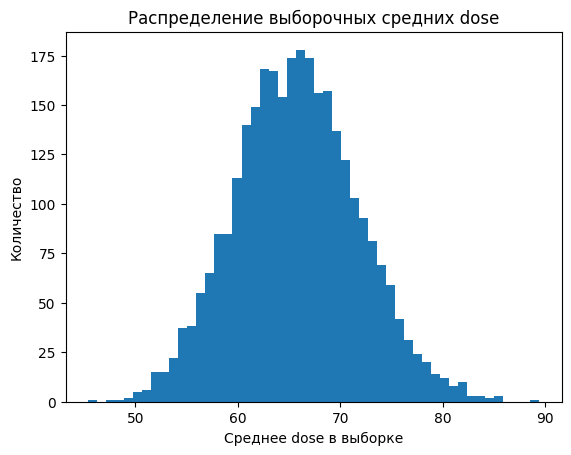

In [ ]:
plt.hist(sample_means, bins=50)
plt.title("Распределение выборочных средних dose")
plt.xlabel("Среднее dose в выборке")
plt.ylabel("Количество")
plt.show()

Вывод:
1. Признак dose имеет большой разброс и выбросы, средние значения по случайным выборкам размером 1000 стабильно концентрируются около общего среднего ≈ 65.8.
2. Колонка dose может быть скошенной и иметь выбросы.